Loading data...
Master dataset created with 66 reported incidents.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_53552\2792643631.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


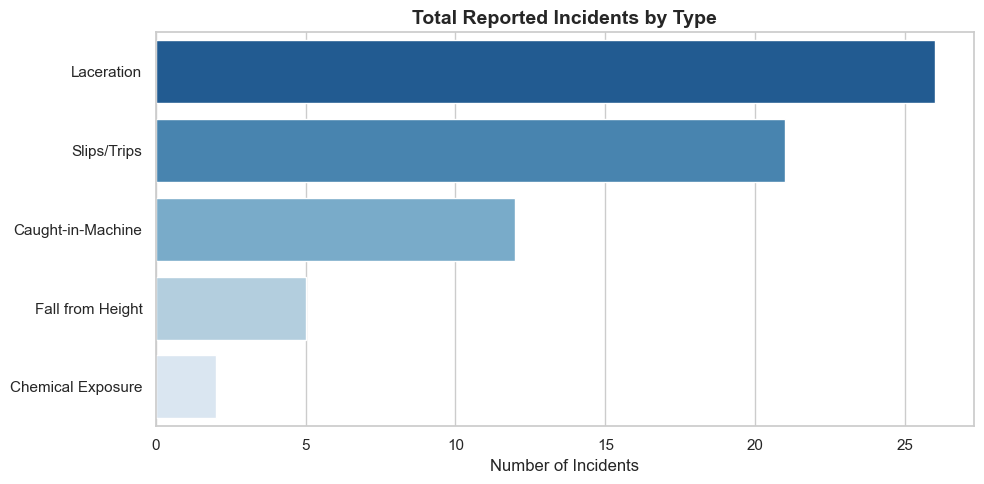

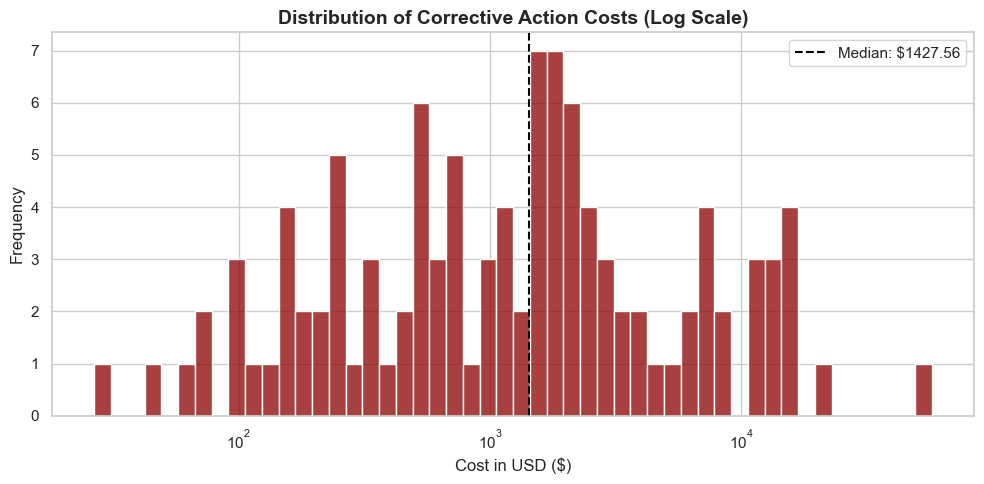

Analyzing human factors and investigation metrics...


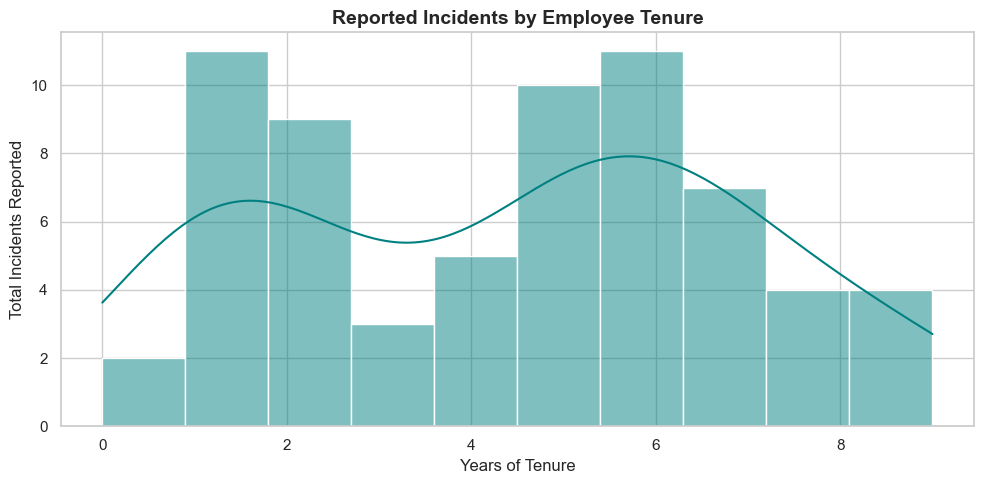

Observation: A massive spike in incidents occurs in the first 2 years of employment, validating the 'Rookie Risk' hypothesis.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_53552\2792643631.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


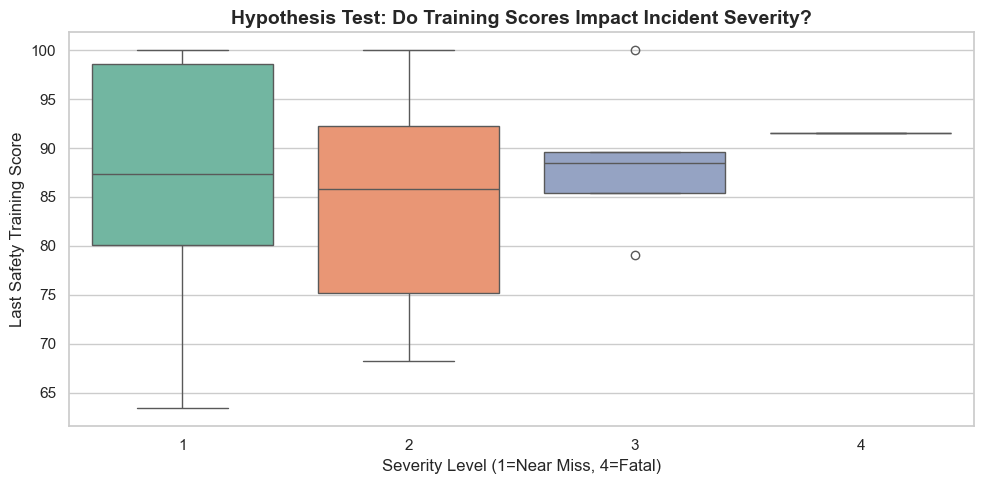

Observation: The boxplots are virtually identical across all severities! This is a classic 'Red Herring'. The training score has no statistical correlation with incident severity in this dataset.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_53552\2792643631.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


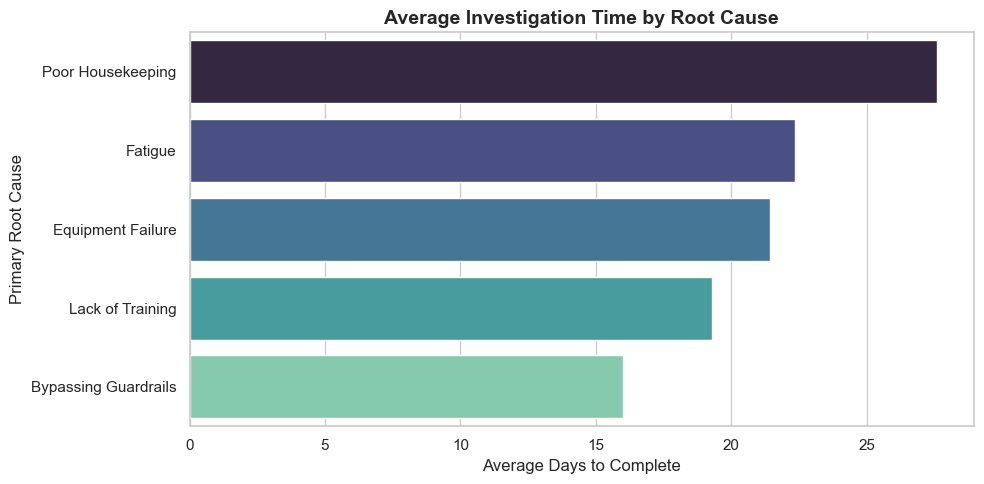

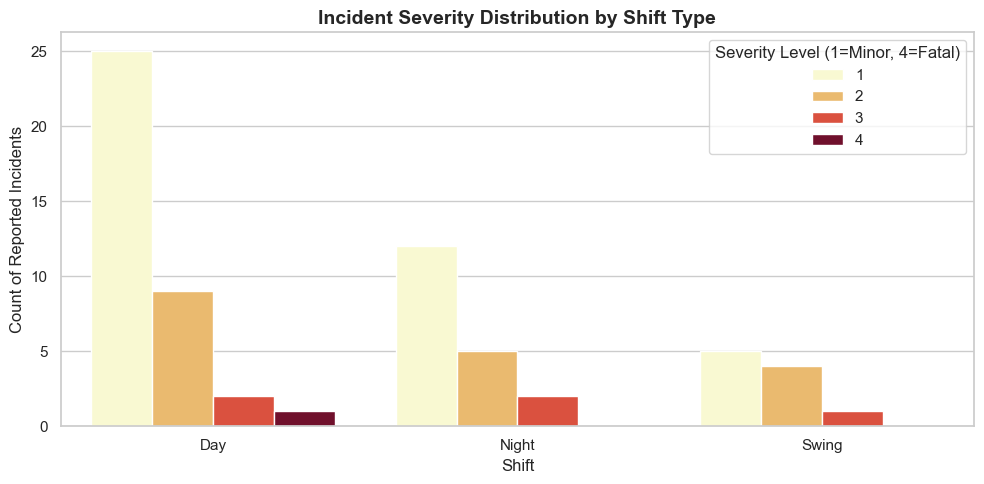

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visual aesthetic for EHS reporting
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 1. LOAD AND MERGE THE DATA
# ==========================================
print("Loading data...")
sites = pd.read_csv('sites.csv')
emps = pd.read_csv('employees.csv')
incidents = pd.read_csv('incidents.csv')
investigations = pd.read_csv('investigations.csv')
actions = pd.read_csv('corrective_actions.csv')

# -> THE FIX: Isolate only the core incident columns <-
incident_cols = [
    'inc_id', 'emp_id', 'date', 'incident_type', 
    'severity_level', 'body_part', 'ppe_compliant'
]
incidents_core = incidents[incident_cols]

# Create a "Master" Analytical Table
# Merge the clean incidents table with employee details, then with site details
df_master = incidents_core.merge(emps, on='emp_id', how='left')
df_master = df_master.merge(sites, on='site_id', how='left')

# Convert timestamp/date to datetime object for later use
df_master['date'] = pd.to_datetime(df_master['date'])

print(f"Master dataset created with {len(df_master)} reported incidents.")

# ==========================================
# 2. BASELINE VISUALIZATION 1: Incident Types
# ==========================================
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df_master, 
    y='incident_type', 
    order=df_master['incident_type'].value_counts().index,
    palette="Blues_r"
)
plt.title("Total Reported Incidents by Type", fontsize=14, fontweight='bold')
plt.xlabel("Number of Incidents")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ==========================================
# 3. BASELINE VISUALIZATION 2: Financial Impact
# ==========================================
# Notice how we use a Log Scale here to handle the massive outliers
# that we generated using np.random.lognormal!
plt.figure(figsize=(10, 5))
sns.histplot(data=actions, x='action_cost_usd', bins=50, log_scale=True, color='darkred')
plt.title("Distribution of Corrective Action Costs (Log Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Cost in USD ($)")
plt.ylabel("Frequency")
# Add a vertical line for the median cost
plt.axvline(actions['action_cost_usd'].median(), color='black', linestyle='--', label=f"Median: ${actions['action_cost_usd'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()
# ==========================================
# 3.5 THE MIDDLE SECTION: Investigating Human Factors & Operations
# ==========================================
print("Analyzing human factors and investigation metrics...")

# --- Analysis A: The Real Driver (Tenure) ---
# We expect newer employees to have more accidents. Let's group by years of tenure.
df_master['tenure_years'] = np.floor(df_master['tenure_months'] / 12)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_master, x='tenure_years', bins=10, color='teal', kde=True)
plt.title("Reported Incidents by Employee Tenure", fontsize=14, fontweight='bold')
plt.xlabel("Years of Tenure")
plt.ylabel("Total Incidents Reported")
plt.tight_layout()
plt.show()

print("Observation: A massive spike in incidents occurs in the first 2 years of employment, validating the 'Rookie Risk' hypothesis.")

# --- Analysis B: The Red Herring (Safety Training) ---
# A junior analyst will assume "Low Training Score = More Severe Accidents". 
# Let's test that hypothesis.
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_master, 
    x='severity_level', 
    y='last_training_score', 
    palette="Set2"
)
plt.title("Hypothesis Test: Do Training Scores Impact Incident Severity?", fontsize=14, fontweight='bold')
plt.xlabel("Severity Level (1=Near Miss, 4=Fatal)")
plt.ylabel("Last Safety Training Score")
plt.tight_layout()
plt.show()

print("Observation: The boxplots are virtually identical across all severities! This is a classic 'Red Herring'. The training score has no statistical correlation with incident severity in this dataset.")

# --- Analysis C: Operational Impact (Investigations) ---
# Merge investigations to see which root causes take the longest to close.
df_investigations = df_master.merge(investigations, on='inc_id', how='inner')

plt.figure(figsize=(10, 5))
# Calculate average days to complete per cause, sort them for a clean chart
order = df_investigations.groupby('primary_cause')['days_to_complete'].mean().sort_values(ascending=False).index

sns.barplot(
    data=df_investigations, 
    y='primary_cause', 
    x='days_to_complete', 
    order=order,
    palette="mako",
    errorbar=None # Clean look without variance lines
)
plt.title("Average Investigation Time by Root Cause", fontsize=14, fontweight='bold')
plt.xlabel("Average Days to Complete")
plt.ylabel("Primary Root Cause")
plt.tight_layout()
plt.show()
# ==========================================
# 4. BASELINE VISUALIZATION 3: Shift Risk
# ==========================================
# Let's see if Night Shift has a proportionately higher severity
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_master, 
    x='shift_type', 
    hue='severity_level', 
    palette="YlOrRd"
)
plt.title("Incident Severity Distribution by Shift Type", fontsize=14, fontweight='bold')
plt.xlabel("Shift")
plt.ylabel("Count of Reported Incidents")
plt.legend(title='Severity Level (1=Minor, 4=Fatal)')
plt.tight_layout()
plt.show()

Analyzing temporal patterns and reporting bias...


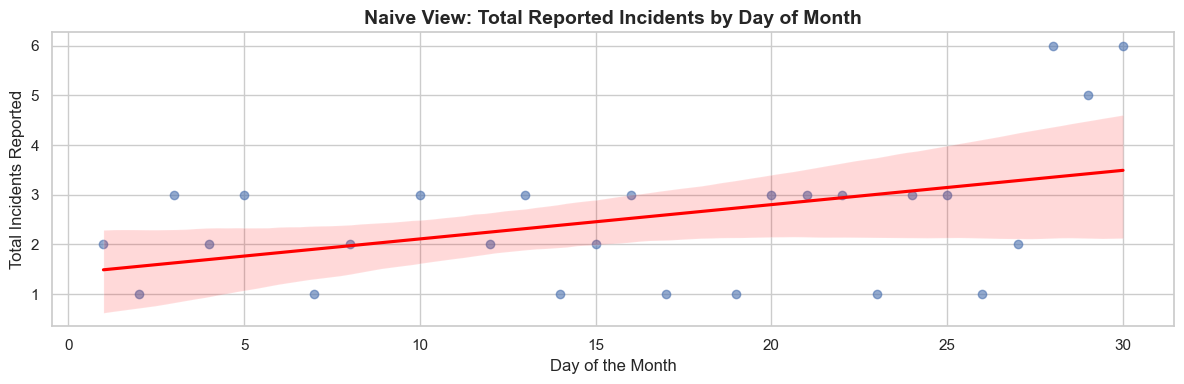

Observation: The total incident count might look noisy or only slightly elevated at month-end. The true spike in accidents is hidden because reporting drops!


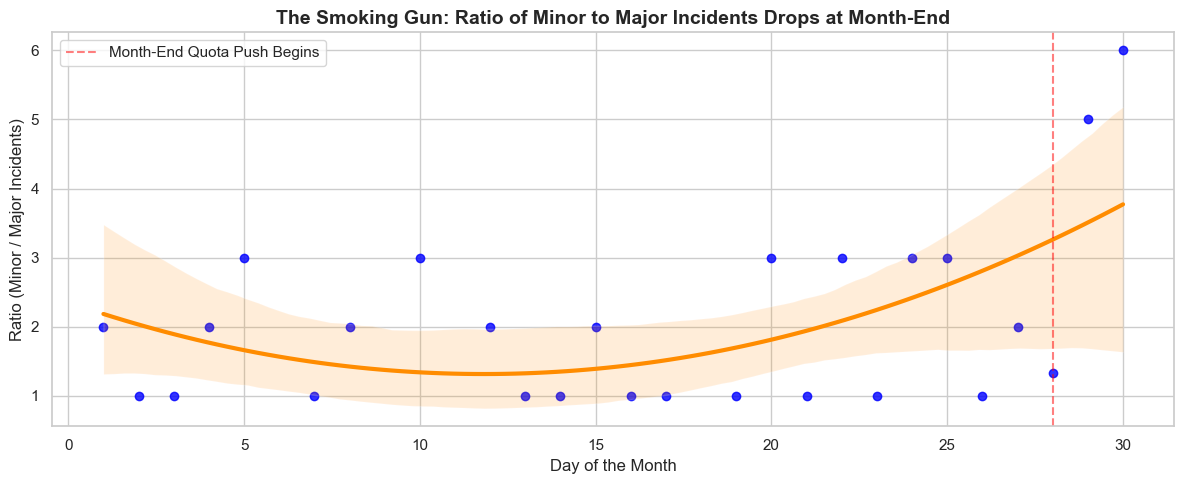

In [4]:
# ==========================================
# 5. THE STRETCH GOAL: Hunting for Omitted Variables
# ==========================================
print("Analyzing temporal patterns and reporting bias...")

# Extract the Day of the Month
df_master['day_of_month'] = df_master['date'].dt.day

# --- PART 1: The Naive View (The Trap) ---
# A junior analyst might just look at total incidents over time
daily_totals = df_master.groupby('day_of_month').size().reset_index(name='total_incidents')

plt.figure(figsize=(12, 4))
sns.regplot(data=daily_totals, x='day_of_month', y='total_incidents', 
            scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})
plt.title("Naive View: Total Reported Incidents by Day of Month", fontsize=14, fontweight='bold')
plt.xlabel("Day of the Month")
plt.ylabel("Total Incidents Reported")
plt.tight_layout()
plt.show()

print("Observation: The total incident count might look noisy or only slightly elevated at month-end. The true spike in accidents is hidden because reporting drops!")

# --- PART 2: The Advanced View (Exposing the Bias) ---
# A senior analyst looks at the RATIO of Minor to Major incidents.
# Major incidents (Severity 3 & 4) MUST be reported.
# Minor incidents (Severity 1 & 2) CAN be hidden by workers.

# Classify Severity into Minor vs Major
df_master['is_major'] = df_master['severity_level'].isin([3, 4])

# Count Minor and Major incidents per day
severity_daily = df_master.groupby(['day_of_month', 'is_major']).size().unstack(fill_value=0)
severity_daily.columns = ['Minor_Reported', 'Major_Reported']

# Calculate the Reporting Ratio (Minor per Major)
# We add 1 to the denominator to avoid division by zero on quiet days
severity_daily['reporting_ratio'] = severity_daily['Minor_Reported'] / (severity_daily['Major_Reported'] + 1)
severity_daily = severity_daily.reset_index()

# Plotting the Smoking Gun
plt.figure(figsize=(12, 5))
sns.regplot(data=severity_daily, x='day_of_month', y='reporting_ratio', 
            scatter_kws={'alpha':0.8, 'color':'blue'}, 
            line_kws={'color': 'darkorange', 'linewidth': 3}, order=2) # order=2 fits a curve
plt.title("The Smoking Gun: Ratio of Minor to Major Incidents Drops at Month-End", fontsize=14, fontweight='bold')
plt.xlabel("Day of the Month")
plt.ylabel("Ratio (Minor / Major Incidents)")
plt.axvline(28, color='red', linestyle='--', alpha=0.5, label='Month-End Quota Push Begins')
plt.legend()
plt.tight_layout()
plt.show()